In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
!pip install -q kaggle

In [4]:
import kagglehub
path=kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print(path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
/kaggle/input/creditcardfraud


In [5]:
import pandas as pd

df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
print("\nShape:", df.shape)

print("\nMissing Values")

print(df.isnull().sum())


Shape: (284807, 31)

Missing Values
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [7]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

# Scale Amount column

scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])

print(df.head())

Dataset Shape: (283726, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

In [8]:
print("\nFraud Distribution")

print(df["Class"].value_counts())


Fraud Distribution
Class
0    283253
1       473
Name: count, dtype: int64


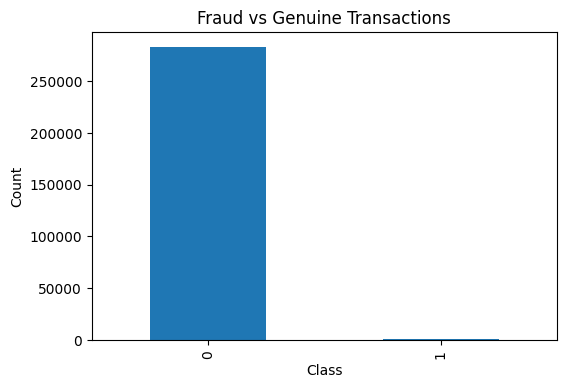

In [9]:
plt.figure(figsize=(6,4))

df["Class"].value_counts().plot(kind="bar")

plt.title("Fraud vs Genuine Transactions")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

In [10]:
print(df.groupby("Class")["Amount"].mean())

Class
0   -0.000236
1    0.141371
Name: Amount, dtype: float64


In [11]:
X = df.drop("Class", axis=1)

y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = RandomForestClassifier(
    n_estimators=1,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=1, random_state=42)

In [13]:
prediction = model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)

Accuracy : 0.9990307686885419


In [15]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.71      0.67      0.69        90

    accuracy                           1.00     56746
   macro avg       0.85      0.83      0.84     56746
weighted avg       1.00      1.00      1.00     56746



In [16]:
print(confusion_matrix(y_test, prediction))

[[56631    25]
 [   30    60]]


In [17]:
sample = X_test.iloc[[10]]

result = model.predict(sample)

if result[0] == 1:
    print("Fraudulent Transaction")
else:
    print("Genuine Transaction")

Genuine Transaction


In [18]:
print("="*50)

print("FRAUD DETECTION REPORT")

print("="*50)

print("Total Transactions :", len(df))

print("Fraud Cases :", df["Class"].value_counts()[1])

print("Genuine Cases :", df["Class"].value_counts()[0])

print("Model Accuracy :", round(accuracy*100,2), "%")

print("\nConclusion")

print("- Random Forest successfully detects fraudulent transactions.")

print("- Fraud transactions are much fewer than genuine transactions.")

print("- Machine learning improves fraud detection accuracy.")

print("- Financial organizations can use this model for real-time fraud detection.")

FRAUD DETECTION REPORT
Total Transactions : 283726
Fraud Cases : 473
Genuine Cases : 283253
Model Accuracy : 99.9 %

Conclusion
- Random Forest successfully detects fraudulent transactions.
- Fraud transactions are much fewer than genuine transactions.
- Machine learning improves fraud detection accuracy.
- Financial organizations can use this model for real-time fraud detection.
